# 08 — An agent in a book that reacts, and the price of being blind

Chapter 05's environment has no book in it.  Fills arrive as a Poisson process
whose rate depends on where the quote sits, the mid diffuses on its own, and
nothing connects a fill to what the price does next.  A maker there is never
picked off.

This one is chapter 04's book with a maker standing in it: the same estimated
intensities, the same measured order sizes, the same regeneration law.  The maker
rests one unit at each best, **its position in the queue is tracked**, and it
trades only once the size in front of it is gone.  When a queue empties the price
moves a tick.

Adverse selection then needs no modelling at all.  Being filled on the bid means
the bid queue was being consumed; a queue being consumed is one on its way to
empty; and a bid queue that empties takes the price down.  The maker is bought
into a falling price by the very mechanism that filled it.

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hfx.viz import subplots, use_style, colour_for, tick_regime
from hfx.pipeline.results import panel, curves, curve, symbol_days
use_style()
P = panel(); C = curves()
DAY = "2019-01-30"
print(f"{len(P)} symbol-days, {P.symbol.nunique()} symbols, {P.date.nunique()} dates")
A = pd.read_csv(os.path.join("..", "results", "agents.csv")).set_index("symbol")
AC = dict(np.load(os.path.join("..", "results", "agents.npz")))
print(f"{len(A)} symbols")

84 symbol-days, 12 symbols, 7 dates
12 symbols


## The environment, rebuilt here and checked against the market

Nothing is loaded from a pickle: the environment is reconstructed from the same
intensity tables the notebook reads off disk.  The first thing to ask is whether
the discrete-time approximation reproduces the continuous-time simulator of
chapter 04 — which was itself compared against the market there, and found to be
faithful on the one-tick names and to under-predict the wide-spread ones.

The environment reflects the queue at the size below which the real book spends
99% of its day.  Without that cap it inherits chapter 04's runaway: above about
ten average sizes the estimated intensities imply a drift of tens of average
sizes per second, an artifact of a few seconds' residence time, and every
simulated book climbs into it and freezes.

In [2]:
from hfx.mm.queue_env import QueueBookEnv, OUT, AT_TOUCH
from hfx.mm import queue_agent as qa

def environment(sym, seed=11, batch=4096, rebate=0.0):
    lam = curve(C, sym, DAY, "qr_lambda")
    seconds = curve(C, sym, DAY, "qr_time") / 1e9
    counts = np.nan_to_num(lam) * seconds                  # rates back to counts
    regen = curve(C, sym, DAY, "qr_regen").sum(axis=0).astype(float)
    return QueueBookEnv.from_tables(counts, seconds * 1e9,
                                    curve(C, sym, DAY, "size_hist"), regen,
                                    dt=0.02, batch=batch, rebate=rebate,
                                    rng=np.random.default_rng(seed))

rows = []
for sym in ["SIRI", "INTC", "CSCO", "MSFT", "AAPL"]:
    env = environment(sym, batch=2048)
    moved = 0
    for _ in range(400):
        _o, _r, info = env.step(np.full(env.batch, OUT), np.full(env.batch, OUT))
        moved += int(info["moved"].sum())
    day = P[(P.symbol == sym) & (P.date == DAY)].iloc[0]
    reference = 1.0 / day.qr_holding_s if day.qr_holding_s > 0 else np.nan
    rows.append({"symbol": sym, "spread (ticks)": day.median_spread_ticks,
                 "queue cap": env.q_max,
                 "this environment, moves/s": moved / (400 * env.dt * env.batch),
                 "chapter 04 simulator, moves/s": reference})
frame = pd.DataFrame(rows)
frame["ratio"] = frame["this environment, moves/s"] / frame["chapter 04 simulator, moves/s"]
print(frame.round(3).to_string(index=False))

symbol  spread (ticks)  queue cap  this environment, moves/s  chapter 04 simulator, moves/s  ratio
  SIRI             1.0       44.0                      0.167                          0.027  6.095
  INTC             1.0       25.0                      0.804                          0.657  1.222
  CSCO             1.0       29.0                      0.472                          0.366  1.288
  MSFT             1.0       35.0                      1.013                          0.716  1.416
  AAPL             2.0       12.0                      2.720                          2.791  0.974


The discrete-time environment tracks the continuous-time simulator to
within 1.0–1.4 on INTC, CSCO, MSFT and AAPL.  SIRI is the exception, at about
six times: its queues are the deepest in the panel — the cap sits at 44 average
sizes against 12 for AAPL — and the two approximations disagree badly out there.
They bracket the market rather than agree with it, the real rate being 0.056
changes a second against 0.027 for the simulator and 0.167 here, so nothing SIRI
contributes below should be read as more than a sign.

## What the maker earns, and what the book is worth

Two families of policy, searched over the **same simulated price paths**.  The
environment's randomness does not depend on the agent — the maker's order is
never part of the queue, so it never changes the book — which makes every
comparison paired and cancels most of the noise.

* **blind**: quote unless the inventory says otherwise.  Exactly the information
  the closed form of chapter 05 uses.
* **sighted**: the same, plus a refusal to bid into a thin bid queue.

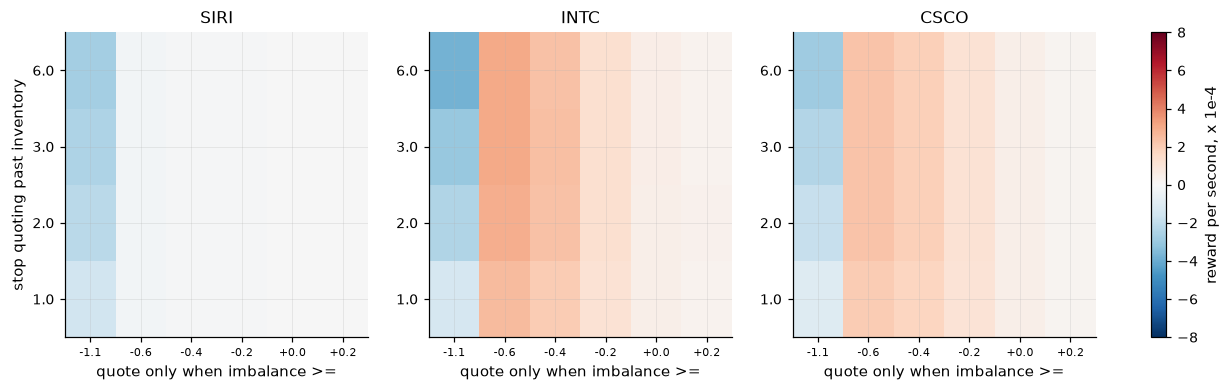

In [3]:
fig, axes = subplots(1, 3, figsize=(13, 3.6))
for ax, sym in zip(axes, ["SIRI", "INTC", "CSCO"]):
    frame = pd.DataFrame(AC[f"{sym}|search"],
                         columns=["inventory_max", "imbalance_min", "reward", "se",
                                  "fills", "inv"])
    pivot = frame.pivot_table(index="inventory_max", columns="imbalance_min", values="reward")
    im = ax.imshow(pivot.to_numpy() * 1e4, origin="lower", cmap="RdBu_r",
                   vmin=-8, vmax=8, aspect="auto")
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([f"{v:+.1f}" for v in pivot.columns], fontsize=7)
    ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index)
    ax.set_title(sym); ax.set_xlabel("quote only when imbalance >=")
axes[0].set_ylabel("stop quoting past inventory")
fig.colorbar(im, ax=axes, label="reward per second, x 1e-4", fraction=0.02)

The left column of each panel is the blind family: no imbalance rule at
all.  It is red everywhere, and it gets *redder* as the maker is allowed to quote
more.  One column to the right — refusing only the most lopsided books — the sign
flips.

In [4]:
show = A[["blind_reward", "sighted_reward", "value_of_sight", "sighted_imbalance_min",
          "blind_fills", "sighted_fills", "blind_se", "sighted_se"]].copy()
for c in ["blind_reward", "sighted_reward", "value_of_sight", "blind_se", "sighted_se"]:
    show[c] *= 1e4
print(show.round(3).to_string())
print(f"\nthe blind maker loses money on {(A.blind_reward < 0).sum()} of {len(A)} symbols")
print(f"seeing the book is worth {A.value_of_sight.median() * 1e4:+.2f}e-4 per second at the "
      f"median, against standard errors of {A[['blind_se', 'sighted_se']].max().max() * 1e4:.3f}e-4")
assert (A.value_of_sight > 0).all()

        blind_reward  sighted_reward  value_of_sight  sighted_imbalance_min  blind_fills  sighted_fills  blind_se  sighted_se
symbol                                                                                                                       
AAPL          -4.355           2.501           6.856                   -0.4        0.627          0.333     0.092       0.050
AMZN          -4.984          -0.881           4.104                    0.2        0.168          0.033     0.152       0.072
CSCO          -1.003           2.299           3.301                   -0.6        0.189          0.096     0.022       0.189
GOOG          -1.817          -0.387           1.429                    0.2        0.090          0.017     0.127       0.009
INTC          -1.366           3.023           4.389                   -0.6        0.261          0.132     0.025       0.021
ISRG          -1.277          -0.179           1.099                    0.2        0.037          0.006     0.047     

## The market-design reading

A rebate is paid per fill and does not change the book, and the environment's
randomness does not depend on the agent, so for any fixed policy

$$\text{reward}(z) = \text{reward}(0) + z \times \text{fills per second}$$

*exactly*.  Each family's frontier is the upper envelope of a set of straight
lines and costs nothing beyond the simulations already run.  Where it crosses zero
is the rebate an exchange would have to pay to keep that kind of maker in business
— which is what chapter 06 solves for, arrived at from the opposite direction.

        break_even_rebate_blind  break_even_rebate_sighted
symbol                                                    
AAPL                       0.07                       0.00
AMZN                       0.30                       0.26
CSCO                       0.06                       0.00
GOOG                       0.21                       0.17
INTC                       0.06                       0.00
ISRG                       0.35                       0.29
MSFT                       0.00                       0.00
MU                         0.00                       0.00
NFLX                       0.25                       0.15
REGN                       0.30                       0.24
SIRI                       0.28                       0.13
TSLA                       0.27                       0.15


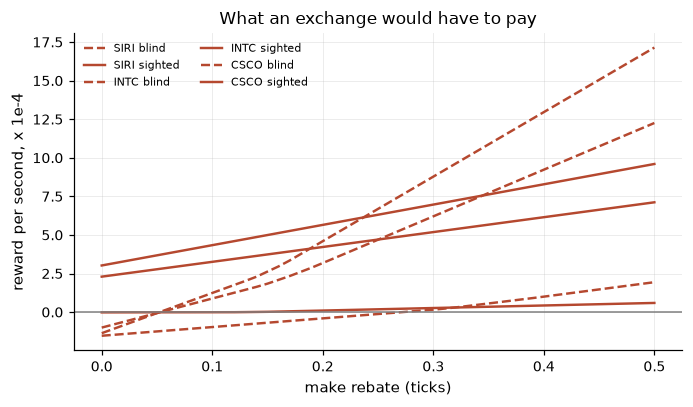

In [5]:
fig, ax = subplots(figsize=(6.4, 3.8))
for sym in ["SIRI", "INTC", "CSCO"]:
    colour = colour_for(P[P.symbol == sym].median_spread_ticks.mean())
    for family, style in [("blind", "--"), ("sighted", "-")]:
        f = AC[f"{sym}|frontier_{family}"]
        ax.plot(f[:, 0] * 100, f[:, 1] * 1e4, style, color=colour, label=f"{sym} {family}")
ax.axhline(0, color="0.5", lw=1)
ax.set_xlabel("make rebate (ticks)"); ax.set_ylabel("reward per second, x 1e-4")
ax.set_title("What an exchange would have to pay"); ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
print(A[["break_even_rebate_blind", "break_even_rebate_sighted"]].mul(100).round(3).to_string())

## The methodological result, which is the one worth carrying away

Four ways of solving this were tried, and only one worked.

The per-step reward is dominated by marking inventory across a price move: with a
few units of inventory and a one-cent tick its standard deviation is near
$3\times10^{-2}$, while the difference in value between two quoting policies is
near $2\times10^{-5}$ per step.  Any method that estimates a value function from
single-step rewards needs of order $(3\times10^{-2}/2\times10^{-5})^2 \approx
10^{6}$ samples **per state-action cell** before its argmax is anything but the
luckiest estimate.

* **Tabular Q-learning** — the algorithm that recovers the closed form in chapter
  05 — undertrades here and is beaten by quoting at the touch unconditionally.
* **Model-based tabular RL**, averaging rewards and then solving, works at 13
  states and fails at 156.
* **A deep Q-network** does not converge: its loss *rises* through training, the
  signature of a bootstrap chasing noise.
* **Direct policy comparison on common random numbers** resolves the same effect
  at sixty standard errors, because the noise is shared between the policies being
  compared and cancels.

None of that is a fact about market making.  It is a fact about where the variance
sits, and it is worth checking before reaching for a learner.

        naive_reward  blind_reward  sighted_reward  deep_reward
symbol                                                         
AAPL          -6.426        -4.355           2.501       -7.972
AMZN          -7.207        -4.984          -0.881       -6.669
CSCO          -2.887        -1.003           2.299       -2.548
GOOG          -2.669        -1.817          -0.387       -2.981
INTC          -3.400        -1.366           3.023       -2.116
ISRG          -1.530        -1.277          -0.179       -0.773
MSFT           3.043         3.220          13.085       -5.787
MU            -0.372         0.322           4.267       -3.036
NFLX          -8.837        -5.481          -0.455       -7.969
REGN          -1.543        -1.351          -0.189       -1.230
SIRI          -2.592        -1.531          -0.017       -1.513
TSLA         -10.037        -6.196          -0.515       -5.781

the deep agent beats the sighted threshold policy on 0 of 12 symbols


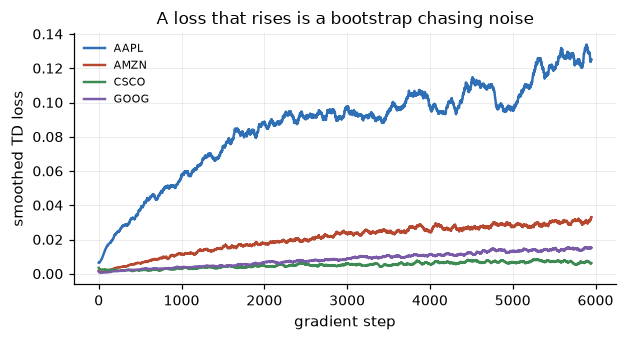

In [6]:
if "deep_reward" in A.columns and A.deep_reward.notna().any():
    print(A[["naive_reward", "blind_reward", "sighted_reward", "deep_reward"]].mul(1e4).round(3).to_string())
    print(f"\nthe deep agent beats the sighted threshold policy on "
          f"{(A.deep_reward > A.sighted_reward).sum()} of {len(A)} symbols")
    fig, ax = subplots(figsize=(5.8, 3.2))
    for sym in list(A.index)[:4]:
        key = f"{sym}|deep_loss"
        if key in AC:
            ax.plot(np.convolve(AC[key], np.ones(50) / 50, mode="valid"), label=sym)
    ax.set_xlabel("gradient step"); ax.set_ylabel("smoothed TD loss")
    ax.set_title("A loss that rises is a bootstrap chasing noise"); ax.legend(fontsize=7)
    plt.tight_layout()
else:
    print("torch not installed: the deep variant is skipped, as it is in CI")

## What this chapter established

In a book whose price moves because queues empty, **a market maker that cannot see
the book loses money at the touch**, and no inventory rule rescues it — quoting
more only loses faster.  A single rule that refuses to buy when the bid queue is
thin turns the same business profitable.  That difference, measured on identical
simulated price paths, is what the order book is worth to a maker.

It also answers chapter 06's question from the other side.  An exchange facing
blind makers must pay them to stay; facing makers who can read the queues, it need
not.  The rebate is the price of the information the maker lacks.